#### End to end machine learning project using t-SNE


1.  t-SNE stands for t Distributed Stochastic Neighbour Embedding.

2.  It can de defined as an unsupervised machine learning algorithm that is used to convert the high dimensional data into low dimensional space so that the patterns, data , relationships and complex inormation can be understood easily.

#### t-SNE Algorithm :--------

(a.) It is a dimensionality reduction algorithm used to convert the high dimensiional features into low dimensional spaces.

(b.) It is used for cluster visualization

(c.) It is used for data visualiation.


#### Principle behind t-SNE

1. Each data point has its own neighbour in the high dimensional space. The same neighbour property must exists in the low dimensional space.

2. The data points that are very far away from each other in high dimensional space must be the same in low dimensional space.


#### Algorithm behind t-SNE :----------

1.  Construct the high dimensional space.

2.  Consider a data point in high dimensional space and find out the neighbors of that data point using euclidean distance.

3.  Then do this for all the data points in the high dimensional points.

4.  The data points that are closer with respect to each other are similar and the data points that are very far away are disimilar .

5. Construct the low dimensional space and take all the data points and its neighbors of that same high dimensional space and try to rearrange them in low dimensional space.

6.  The data points must be rearranged in such a way that the negighbourhood property in the high dimensional space must exist in the low dimensional space.

#### Difference between PCA and t-SNE


| PCA                              | t-SNE                                                                            |
| -------------------------------- | -------------------------------------------------------------------------------- |
| 1. It preserves the variance.    | It preserves the similarity.                                                     |


#### Problem  Statement :---

(1.) The main aim of the problem statement is to reduce the number of input features in the wine dataset from 13 to 2.

(2.) Then reserve the neighbourhood properties of the data points

    (a.)    Similar data points are closer together.

    (b.)    Dissimilar data points are far apart.


#### Step 1: Import all the necessary libraries

In [665]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.datasets                import  load_wine
from    sklearn.model_selection         import  train_test_split,   GridSearchCV,   StratifiedKFold
from    sklearn.preprocessing           import  StandardScaler
from    sklearn.manifold                import  TSNE

#### OBSERVATIONS:

1.  TSNE ===============>   

    (a.)    It is used for dimensionality reduction.

    (b.)    It preserves the similarity.

    (c.)    It works better when all the input features are scaled properly.

#### Step 2: Load the dataset

In [666]:
#### extract the data

data = load_wine()

#### Construct the dataframe from the data
df = pd.DataFrame(data.data, columns=data.feature_names)

#### Adding the target to the dataset
df['target']    =   data.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


#### OBSERVATIONS:

1.  The above dataset explains about all the details of the wine quality dataset.

2.  Wine Dataset Features Explanation

| Feature Name                     | One-Line Explanation                                                             |
| -------------------------------- | -------------------------------------------------------------------------------- |
| **alcohol**                      | Percentage of alcohol present in the wine.                                       |
| **malic_acid**                   | Amount of malic acid contributing to wine’s sour taste.                          |
| **ash**                          | Total mineral content remaining after burning the wine residue.                  |
| **alcalinity_of_ash**            | Measure of the alkalinity (basicity) of the ash content.                         |
| **magnesium**                    | Concentration of magnesium mineral present in the wine.                          |
| **total_phenols**                | Total amount of phenolic compounds affecting flavor and antioxidant properties.  |
| **flavanoids**                   | Quantity of flavonoids responsible for color and taste characteristics.          |
| **nonflavanoid_phenols**         | Amount of non-flavonoid phenolic compounds in the wine.                          |
| **proanthocyanins**              | Concentration of antioxidant compounds influencing bitterness and astringency.   |
| **color_intensity**              | Measure of the depth or richness of the wine color.                              |
| **hue**                          | Ratio describing the shade or tone of the wine color.                            |
| **od280/od315_of_diluted_wines** | Optical density ratio used to estimate wine quality and phenolic concentration.  |
| **proline**                      | Amount of proline amino acid present, often linked to wine maturity and quality. |
| **target**                       | Wine class/category label representing different wine cultivars.                 |

#### Step 3: Perform the Data Exploration

In [667]:
#### get the first five rows of the dataset

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [668]:
#### get the last five rows of the dataset

df.tail()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.7,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.3,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.2,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.3,0.60,1.62,840.0,2
177,14.13,4.10,2.74,24.5,96.0,2.05,0.76,0.56,1.35,9.2,0.61,1.60,560.0,2


In [669]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 178


In [670]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (178, 14)


In [671]:
#### get the columns used in the dataset

df.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='str')

In [672]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

#### OBSERVATIONS:

1.  All the independent or the input features are floating in nature.

2.  But the dependent feature or the target is integer in nature.

In [673]:
#### get the descriptive summary statistics about each numerical column in the dataset

df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


#### OBSERVATIONS:

1.  The above table explains the summary of the statistical summary for each numerical column in the dataset.

#### Step 4: Perform Feature Engineering and Data Cleaning

In [674]:
### Rename 'od280/od315_of_diluted_wines' to 'diluted_wines' 

df.rename(columns={"od280/od315_of_diluted_wines":"diluted_wines"},inplace=True)

In [675]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


#### OBSERVATIONS:

1.  The column name "od280/od315_of_diluted_wines" has been renamed to "diluted_wines" in the dataset.

In [676]:
#### Check for all the NULL records used in the dataset

df.isnull().sum()

alcohol                 0
malic_acid              0
ash                     0
alcalinity_of_ash       0
magnesium               0
total_phenols           0
flavanoids              0
nonflavanoid_phenols    0
proanthocyanins         0
color_intensity         0
hue                     0
diluted_wines           0
proline                 0
target                  0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [677]:
#### Check for the duplicate records in the dataset

df[df.duplicated()]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,diluted_wines,proline,target


#### OBSERVATIONS:

1.  There are no duplicate records used in the dataset.

#### Step 5: Perform Exploratory Data Analysis (EDA)

In [678]:
#### To get the correlation between all the numeric columns used in the dataset

df.corr()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,diluted_wines,proline,target
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720,-0.328222
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011,0.437776
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626,-0.049643
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597,0.517859
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351,-0.209179
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115,-0.719163
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193,-0.847498
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385,0.489109
proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417,-0.499130
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100,0.265668


#### OBSERVATIONS:

1.  The above table explains the summary about the correlation for each numerical columns used in the dataset.

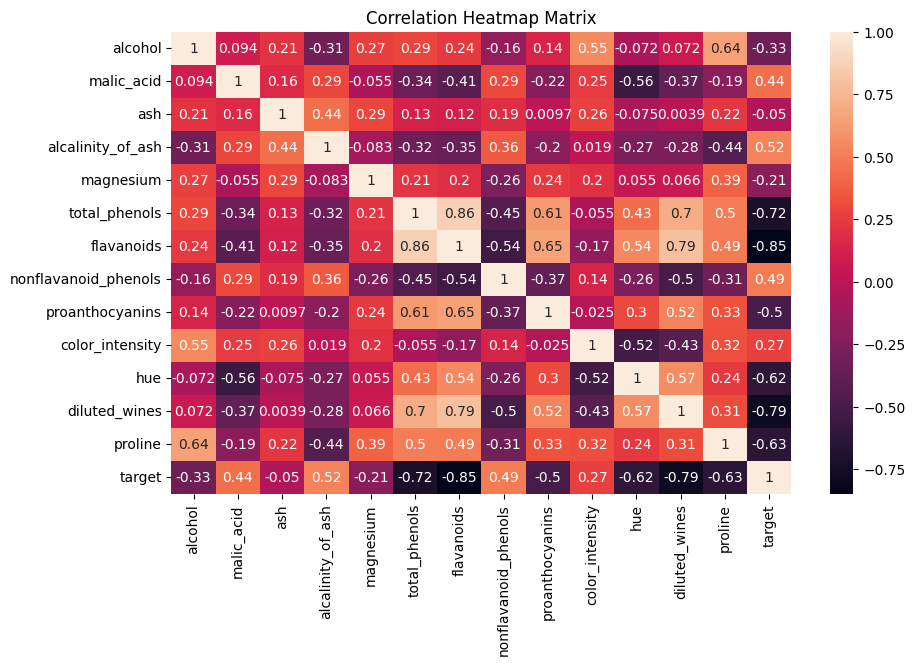

In [679]:
#### To get the graphical representation about the correlation between all the numeric columns used in the dataset

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True)
plt.title("Correlation Heatmap Matrix")
plt.show()

#### OBSERVATIONS:

1.  The above table explains about the correlation between all the numerical columns used in the dataset in a graphical manner.

In [680]:
#### To get the count of all the categories in the target column

df['target'].value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

#### OBSERVATIONS:

1.  There are three categories of wine used in the dataset.

#### Step 6: Divide the dataset into independent and dependent features

In [681]:
#### independent features

X = df.drop(columns='target')

In [682]:
X

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [683]:
#### dependent features

Y = df['target']

In [684]:
Y

0      0
1      0
2      0
3      0
4      0
      ..
173    2
174    2
175    2
176    2
177    2
Name: target, Length: 178, dtype: int64

#### OBSERATIONS:

1.  The dataset is divided into independent features ranging from

| Feature Name                     | One-Line Explanation                                                             |
| -------------------------------- | -------------------------------------------------------------------------------- |
| **alcohol**                      | Percentage of alcohol present in the wine.                                       |
| **malic_acid**                   | Amount of malic acid contributing to wine’s sour taste.                          |
| **ash**                          | Total mineral content remaining after burning the wine residue.                  |
| **alcalinity_of_ash**            | Measure of the alkalinity (basicity) of the ash content.                         |
| **magnesium**                    | Concentration of magnesium mineral present in the wine.                          |
| **total_phenols**                | Total amount of phenolic compounds affecting flavor and antioxidant properties.  |
| **flavanoids**                   | Quantity of flavonoids responsible for color and taste characteristics.          |
| **nonflavanoid_phenols**         | Amount of non-flavonoid phenolic compounds in the wine.                          |
| **proanthocyanins**              | Concentration of antioxidant compounds influencing bitterness and astringency.   |
| **color_intensity**              | Measure of the depth or richness of the wine color.                              |
| **hue**                          | Ratio describing the shade or tone of the wine color.                            |
| **od280/od315_of_diluted_wines** | Optical density ratio used to estimate wine quality and phenolic concentration.  |
| **proline**                      | Amount of proline amino acid present, often linked to wine maturity and quality. |

2.The dataset has also the dependent feature

| Feature Name                     | One-Line Explanation                                                             |
| -------------------------------- | -------------------------------------------------------------------------------- |
| **target**                      | Category of wine quality data             .                                       |

#### Step 7: Perform the Feature Scaling on the inputs

In [685]:
from    sklearn.preprocessing   import  StandardScaler

#### Create an object for Stanadard Scaler

sc = StandardScaler()

#### Using the object of Standard Scaler, transform the inputs

X_scaled = sc.fit_transform(X)

In [686]:
X_scaled

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]], shape=(178, 13))

#### OBSERVATIONS:

1.  Feature Scaling is done directly on the input without dividing the dataset into training and testing data. This is because:------

    (a.)    The size of the dataset is very small. The length is 178.

    (b.)    So there is no need to divide the dataset into training and testing data.


2. t-SNE works on distance estimation. So for doing that proper feature scaling must be done on all the inputs.

In [687]:
X_scaled.shape

(178, 13)

#### Step 8: Apply t-SNE on the scaled input data

In [688]:
from sklearn.manifold import  TSNE

#### Create an object for TSNE

tsne = TSNE(
    n_components    =   2   ,
    perplexity      =   30  ,
    learning_rate   =   200 ,
    random_state    =    42
)


#### using the object of tsne, transform the input
X_tsne = tsne.fit_transform(X_scaled)

#### OBSERVATIONS:

1.  The object of tsne is created with the help of following parameters :-------

    (a.)  n_components = 2 ================>   Number of reduced input features to be 2.

    (b.)  perplexity   = 30 ===============>   Controls the neighbour size. The number of neighbors ranges from 5 to 50. 

    (c.)  learning_rate = 200 =============>   Controls the optimization process.

    (d.)  random_state = 42 ===============>    ensures the reproducibility.

In [689]:
X_tsne

array([[ 1.21775894e+01,  4.59893990e+00],
       [ 7.83211803e+00,  4.45575619e+00],
       [ 9.82392216e+00,  9.24048996e+00],
       [ 1.27186670e+01,  7.29730129e+00],
       [ 5.62557316e+00,  8.85800552e+00],
       [ 1.19117289e+01,  7.89381981e+00],
       [ 9.39052868e+00,  6.44190836e+00],
       [ 8.85268021e+00,  4.90537310e+00],
       [ 1.00238256e+01,  6.32908249e+00],
       [ 1.07389107e+01,  6.22731972e+00],
       [ 1.09978971e+01,  8.60397243e+00],
       [ 8.51586723e+00,  6.42722034e+00],
       [ 8.89340210e+00,  6.96084976e+00],
       [ 1.34949226e+01,  8.90901661e+00],
       [ 1.30187578e+01,  8.87897873e+00],
       [ 8.12701607e+00,  8.70758343e+00],
       [ 8.46996117e+00,  9.59288883e+00],
       [ 8.03656101e+00,  9.46079731e+00],
       [ 1.19711447e+01,  8.56173229e+00],
       [ 1.04724112e+01,  3.35859466e+00],
       [ 1.19225540e+01,  4.54286814e+00],
       [ 7.05515146e+00,  2.64301395e+00],
       [ 8.32567978e+00,  5.57741880e+00],
       [ 6.

#### OBSERVATIONS:

1.  After applying tsne we have reduced the number of input features from 13 to 2.

In [690]:
print("Shape of the input features before applying tsne is:", X_scaled.shape)

print("Shape of the input features after applying tsne is:", X_tsne.shape)

Shape of the input features before applying tsne is: (178, 13)
Shape of the input features after applying tsne is: (178, 2)


#### Step 9: Create the DataFrame for t-SNE

In [691]:
tsne_df = pd.DataFrame()         #### empty dataframe

#### Fill the first column of TSNE with the first component

tsne_df['TSNE1'] = X_tsne[:,0]

#### Fill the second column of tsne with the second component

tsne_df['TSNE2'] = X_tsne[:,1]

#### Add the target into the dataframe

tsne_df['target'] = Y.values

#### Display the dataframe
tsne_df.head()

,TSNE1,TSNE2,target
0,12.177589,4.598940,0
1,7.832118,4.455756,0
2,9.823922,9.240490,0
3,12.718667,7.297301,0
4,5.625573,8.858006,0


#### OBSERVATIONS:

1.  The empty dataframe named "tsne_df" is created.

2.  The first column of "tsne_df" is filled with the first component of tsne.

3.  The second column of "tsne_df" is filled with the second component of tsne.

4.  The target value of the dataframe is filled from the dependent variable.

5.  Then the entire dataframe for tsne is created

#### Step 10: Calculate the count of each category in the target column

In [692]:
tsne_df['target'].value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

#### OBSERVATIONS:

1.  The count of the each category in the target column of the tsne_df dataset is calculated.

#### Step 11: Visualize the t-SNE Output

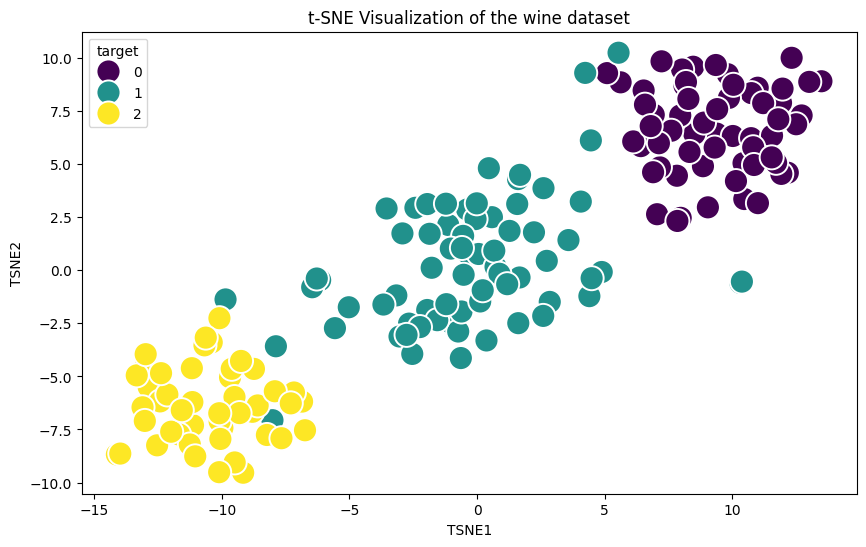

In [693]:
plt.figure(figsize=(10,6))

#### perform the scatterplot of the tsne output
sns.scatterplot(
    x       = 'TSNE1'             ,
    y       = 'TSNE2'             ,
    hue     = 'target'            ,
    data    =  tsne_df            ,
    palette =  'viridis'          ,
    s       =  300               
)

#### give the title of the graph
plt.title("t-SNE Visualization of the wine dataset")

plt.show()

#### OBSERVATIONS:

1.  After applying t-SNE on the wine dataset, three well seperated clusters are formed.

    (a.)    Cluster 0 ====================> It is the densely created cluster formed on the top right.

    (b.)    Cluster 1 ====================> It is formed at the middle sharing some of the properties with cluster 0 and cluster 2.

    (c.)   Cluster 2 ====================> It is the clerly seperable cluster ormed at botton left.


2. t-SNE is highly efective for 

    (a.) high dimensional data visualization

    (b.) cluster recovery
